# Clase teórica 3

En esta clase vamos a ver:
- Cálculo numérico en Numpy
- Manejo de dataframes en Pandas
- Gráficos en `Matplotlib`

## Cálculo numérico en `NumPy`
En esta sección, vamos a usar la librería `NumPy`. Para instalarla, ejecutar en la consola 
- `conda install -c anaconda numpy`, o
- `pip install numpy`,

aunque ya debería estar instalada ya que es una dependencia de `Pandas` (es decir, cuando instalaron `Pandas` se instaló también `NumPy` porque `Pandas` depende de `NumPy`).

Una vez instalada, la importamos:

In [51]:
import numpy as np
print(f"Tenemos instalada la versión {np.__version__} de NumPy.")

Tenemos instalada la versión 1.23.3 de NumPy.


Ejecutemos la siguiente instrucción para que cuando hagamos `print` los números aparezcan con sólo 3 decimales y sean más fáciles de leer:

In [52]:
np.set_printoptions(precision=3)

### Arrays multidimensionales: la clase `ndarray`
NumPy implementa una clase llamada `ndarray` (por array _n_-dimensional).

#### Vectores, matrices y tensores

Definimos un **vector**:

In [53]:
vector = np.array((1.,2,3,4))

In [54]:
print(vector)

[1. 2. 3. 4.]


In [55]:
vector.dtype

dtype('float64')

In [56]:
print("vector ndim:", vector.ndim)
print("vector shape:", vector.shape)
print("vector size:", vector.size)

vector ndim: 1
vector shape: (4,)
vector size: 4


Definimos una **matriz** (tensor de rango 2):

In [57]:
matriz = np.array([[1,2,3], [4,5,6]])
print(matriz)

[[1 2 3]
 [4 5 6]]


In [58]:
print("matriz ndim:", matriz.ndim)
print("matriz shape:", matriz.shape)
print("matriz size:", matriz.size)

matriz ndim: 2
matriz shape: (2, 3)
matriz size: 6


Definamos un **tensor de rango 3**:

In [59]:
tensor3 = np.array([[[-1,-2], [-3,-4]], [[0,0], [0,0]], [[2,1], [1,5]]])

In [60]:
print("tensor3 ndim:", tensor3.ndim)
print("tensor3 shape:", tensor3.shape)
print("tensor3 size:", tensor3.size)

tensor3 ndim: 3
tensor3 shape: (3, 2, 2)
tensor3 size: 12


In [61]:
print(tensor3)

[[[-1 -2]
  [-3 -4]]

 [[ 0  0]
  [ 0  0]]

 [[ 2  1]
  [ 1  5]]]


#### Otras formas de inicializar arrays

Definamos un tensor de todos ceros:

In [62]:
todos_ceros = np.zeros((2,3))
print(todos_ceros)

[[0. 0. 0.]
 [0. 0. 0.]]


Definamos un tensor de todos unos:

In [63]:
todos_unos = np.ones((2,2,3))
print(todos_unos)

[[[1. 1. 1.]
  [1. 1. 1.]]

 [[1. 1. 1.]
  [1. 1. 1.]]]


Definamos un tensor inicialmente vacío...

In [64]:
tensor_por_filas = np.empty((4,5))
print(tensor_por_filas)

[[16.191  0.    16.191  0.    16.191]
 [ 0.    16.219  0.    16.219  0.   ]
 [16.219  1.    16.219  1.    16.191]
 [ 1.    16.191  1.    16.191  0.   ]]


...y luego usemos un ciclo for para llenar las filas una a una:

In [65]:
for i in range(tensor_por_filas.shape[0]):
    tensor_por_filas[i] = i # equivalente a tensor[i,:]

print(tensor_por_filas)

[[0. 0. 0. 0. 0.]
 [1. 1. 1. 1. 1.]
 [2. 2. 2. 2. 2.]
 [3. 3. 3. 3. 3.]]


Podemos hacer algo similar para las columnas:  

In [66]:
tensor_por_columnas = np.empty((4,3))
for i in range(tensor_por_columnas.shape[1]):
    tensor_por_columnas[:,i] = i # acá el : es necesario

print(tensor_por_columnas)

[[0. 1. 2.]
 [0. 1. 2.]
 [0. 1. 2.]
 [0. 1. 2.]]


Definamos un **tensor aleatorio** (más acerca de esto más adelante):

In [67]:
a = np.random.rand(2,3)
b = np.random.rand(2,3)

In [68]:
print(a, "\n\n", b)

[[0.348 0.47  0.6  ]
 [0.895 0.133 0.879]] 

 [[0.188 0.66  0.69 ]
 [0.13  0.451 0.671]]


### Operaciones con arrays

#### Aritmética de arrays

In [69]:
a + b

array([[0.536, 1.13 , 1.291],
       [1.025, 0.584, 1.55 ]])

In [70]:
a - b

array([[ 0.159, -0.19 , -0.09 ],
       [ 0.765, -0.318,  0.208]])

In [71]:
a * b

array([[0.066, 0.31 , 0.414],
       [0.117, 0.06 , 0.59 ]])

In [72]:
a / b

array([[1.844, 0.712, 0.869],
       [6.87 , 0.295, 1.31 ]])

In [73]:
a ** b

array([[0.819, 0.608, 0.703],
       [0.986, 0.403, 0.917]])

In [74]:
a > 0.5

array([[False, False,  True],
       [ True, False,  True]])

In [75]:
2 * a + 3

array([[3.695, 3.94 , 4.2  ],
       [4.79 , 3.266, 4.758]])

#### Indexado

Indexado básico: extraer elementos individuales:

In [76]:
a[0][0]

0.34767027172147313

Indexado con booleanos (como en Pandas):

In [77]:
print(a)
a[a > 0.5]

[[0.348 0.47  0.6  ]
 [0.895 0.133 0.879]]


array([0.6  , 0.895, 0.879])

Indexado con _slices_ (rebanadas):

In [78]:
a[:,1:3]

array([[0.47 , 0.6  ],
       [0.133, 0.879]])

_Fancy indexing_ :

In [79]:
a[:,[0,2]]

array([[0.348, 0.6  ],
       [0.895, 0.879]])

### El submódulo `linalg` para álgebra lineal

In [80]:
# Esto no es necesario porque ya importamos todo numpy antes
# Pero es lo que tendríamos que correr para importar ese submódulo en particular.
# import numpy.linalg

In [81]:
a = np.random.rand(2,3)
b = np.random.rand(3,2)

In [82]:
c = a.dot(b)

In [83]:
np.linalg.inv(c).dot(c)

array([[ 1.000e+00,  2.655e-16],
       [-5.454e-17,  1.000e+00]])

In [84]:
np.linalg.eigvals(c)

array([-0.19 ,  1.029])

In [85]:
np.linalg.eigvals(np.linalg.inv(c))

array([-5.258,  0.972])

In [86]:
from numpy.linalg import inv

In [87]:
inv(c).dot(c)

array([[ 1.000e+00,  2.655e-16],
       [-5.454e-17,  1.000e+00]])

### Números aleatorios: submódulo `random`

In [88]:
import numpy.random # ídem linalg
import matplotlib.pyplot as plt

In [89]:
import random

In [90]:
np.random.rand(2,3,4)

array([[[0.737, 0.087, 0.35 , 0.521],
        [0.192, 0.773, 0.838, 0.746],
        [0.168, 0.859, 0.915, 0.489]],

       [[0.95 , 0.151, 0.16 , 0.301],
        [0.935, 0.666, 0.153, 0.292],
        [0.2  , 0.657, 0.454, 0.932]]])

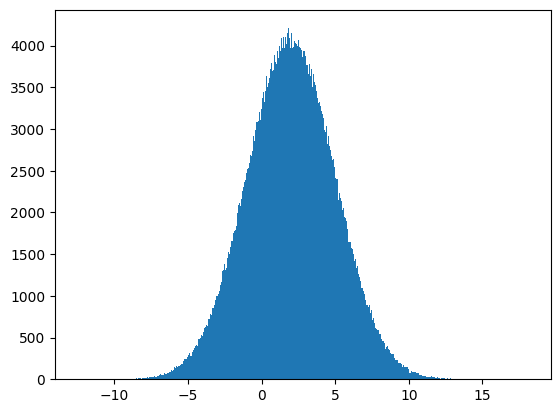

In [91]:
plt.hist(np.random.randn(1000000)*3+2, bins=1000)
plt.show()